# Customer Churn Prediction Using Machine Learning

## Project Objective

Customer churn refers to customers leaving a company's services. Retaining customers is generally more cost-effective than acquiring new ones. Therefore, predicting churn is an important business problem.

The objective of this project is to analyze customer data, identify factors contributing to churn, and build machine learning models that can predict whether a customer is likely to leave the company.

The project will follow a complete data science workflow including:

* Data Collection
* Data Cleaning
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Model Building
* Model Evaluation
* Streamlit Deployment

The target variable is:

**Churn**

* Yes = Customer Left
* No = Customer Stayed

Machine Learning Models:

1. Logistic Regression
2. Decision Tree Classifier


In [1]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

## Loading Dataset

In this step, the dataset is loaded into a Pandas DataFrame so that it can be explored and analyzed. Pandas provides powerful tools for handling structured data.


In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understanding Dataset Structure

Before performing any analysis, it is important to understand the size, columns, and data types present in the dataset.


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nul

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include='object')

C:\Users\Hasnain Ahmed Ansari\AppData\Local\Temp\ipykernel_6876\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Check Missing Values

Missing values can affect analysis and machine learning performance. Therefore, identifying missing values is an essential part of data cleaning.

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df["TotalCharges"].unique()

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

## Handling Invalid Values

The TotalCharges column contains blank spaces that should be converted into missing values before analysis.

In [12]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"].dtype

dtype('float64')

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## Handling Missing Values

Since only a few records contain missing values, removing them will not significantly affect the dataset.

In [15]:
df.dropna(inplace=True)

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.shape

(7032, 21)

## Duplicate Check

Duplicate records may bias the analysis and model performance. Therefore, duplicate observations should be identified and removed if present.

In [17]:
df.duplicated().sum()

np.int64(0)

-----

# EDA STARTS HERE

------

## Target Variable Analysis

Understanding the distribution of the target variable helps determine whether the dataset is balanced or imbalanced.

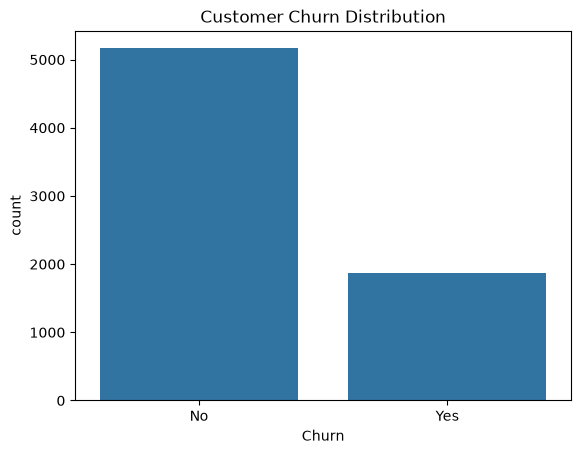

In [18]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

## Numerical Features Analysis

Numerical variables are analyzed to understand their distributions and identify potential patterns.

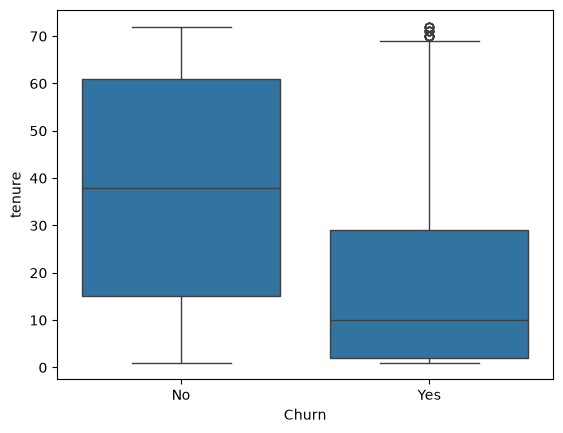

In [19]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.show()

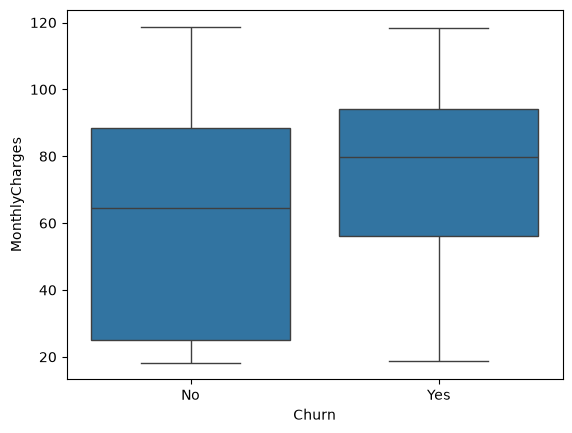

In [20]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

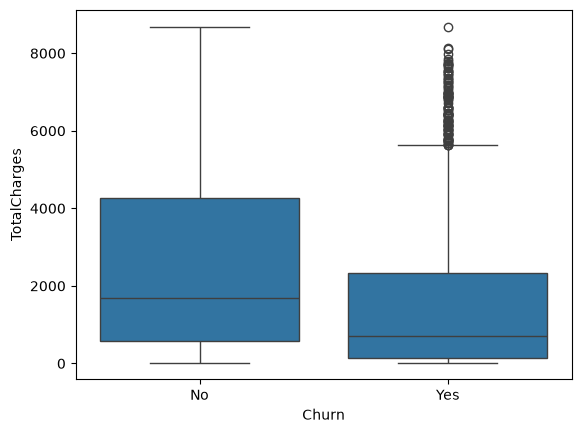

In [21]:
sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.show()

In [32]:
df.groupby('Churn')[
    ['tenure','MonthlyCharges','TotalCharges']
].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


## Relationship Between Features and Churn

Understanding which variables influence churn is important for business decision-making.

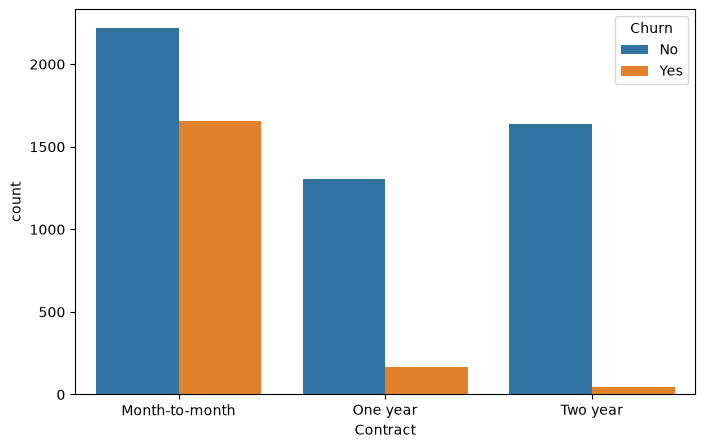

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.show()

In [27]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


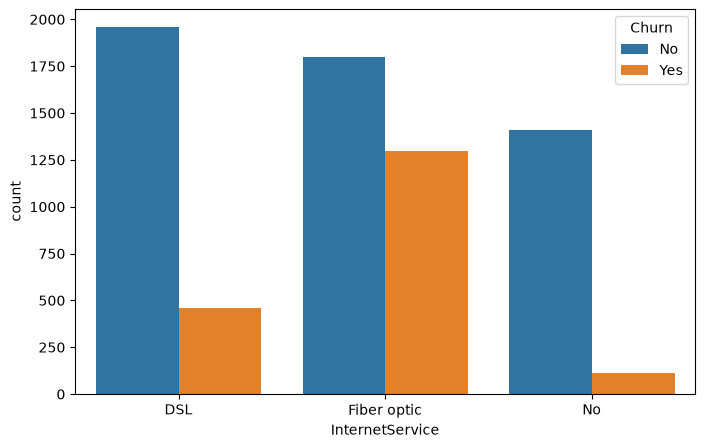

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

In [28]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


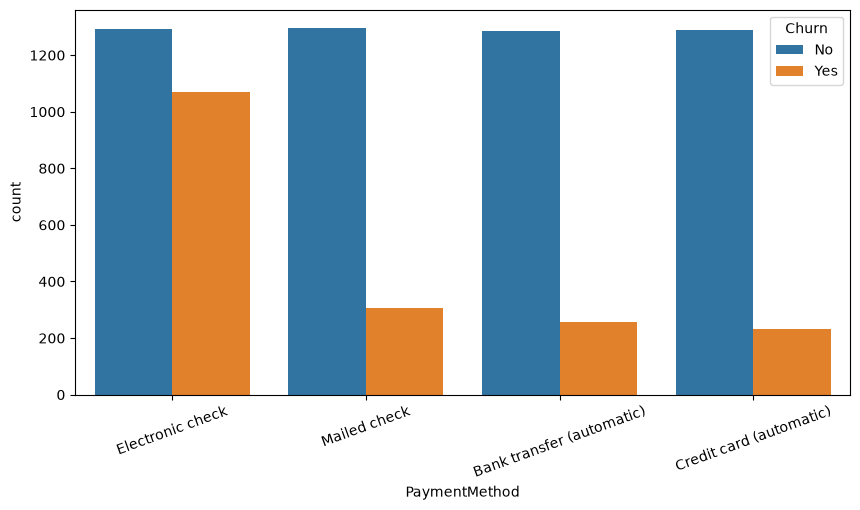

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)

plt.show()

In [30]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


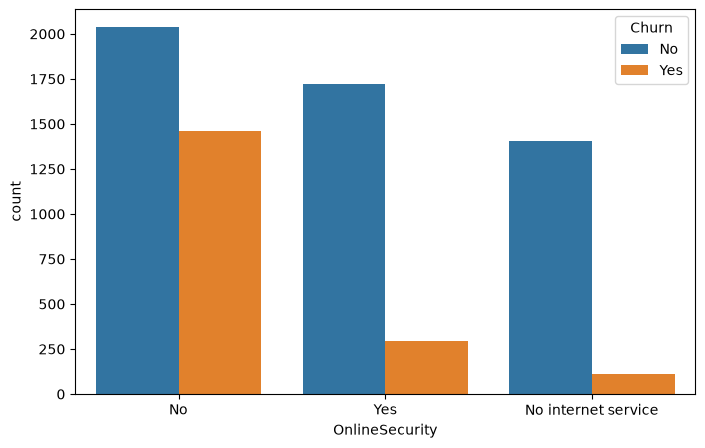

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OnlineSecurity',
    hue='Churn',
    data=df
)

plt.show()

In [29]:
pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


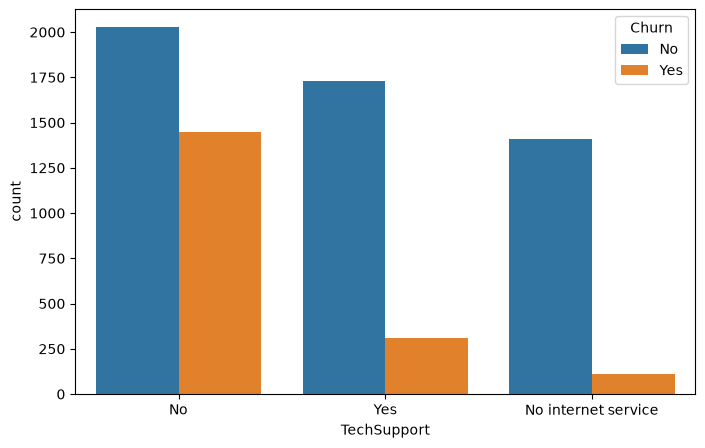

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)

plt.show()

In [31]:
pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


## Feature Selection

Based on exploratory data analysis, only the most influential features were selected for model training.

Features were selected according to their observed relationship with customer churn.

This reduces dataset complexity and improves interpretability.

In [33]:
selected_df = df[[
    'Contract',
    'InternetService',
    'OnlineSecurity',
    'TechSupport',
    'PaymentMethod',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]]

selected_df.head()

,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Churn
0,Month-to-month,DSL,No,No,Electronic check,1,29.85,29.85,No
1,One year,DSL,Yes,No,Mailed check,34,56.95,1889.50,No
2,Month-to-month,DSL,Yes,No,Mailed check,2,53.85,108.15,Yes
3,One year,DSL,Yes,Yes,Bank transfer (automatic),45,42.30,1840.75,No
4,Month-to-month,Fiber optic,No,No,Electronic check,2,70.70,151.65,Yes


In [34]:
selected_df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Contract         7032 non-null   str    
 1   InternetService  7032 non-null   str    
 2   OnlineSecurity   7032 non-null   str    
 3   TechSupport      7032 non-null   str    
 4   PaymentMethod    7032 non-null   str    
 5   tenure           7032 non-null   int64  
 6   MonthlyCharges   7032 non-null   float64
 7   TotalCharges     7032 non-null   float64
 8   Churn            7032 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 900.5 KB


-----------

## Pre-Processing

-----------

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
contract_encoder = LabelEncoder()

selected_df['Contract'] = contract_encoder.fit_transform(
    selected_df['Contract']
)

In [37]:
internet_encoder = LabelEncoder()

selected_df['InternetService'] = internet_encoder.fit_transform(
    selected_df['InternetService']
)

In [39]:
security_encoder = LabelEncoder()

selected_df['OnlineSecurity'] = security_encoder.fit_transform(
    selected_df['OnlineSecurity']
)

In [40]:
support_encoder = LabelEncoder()

selected_df['TechSupport'] = support_encoder.fit_transform(
    selected_df['TechSupport']
)

In [41]:
payment_encoder = LabelEncoder()

selected_df['PaymentMethod'] = payment_encoder.fit_transform(
    selected_df['PaymentMethod']
)

In [42]:
churn_encoder = LabelEncoder()

selected_df['Churn'] = churn_encoder.fit_transform(
    selected_df['Churn']
)

In [43]:
import pickle

In [44]:
pickle.dump(
    contract_encoder,
    open("contract_encoder.pkl","wb")
)

In [45]:
pickle.dump(
    internet_encoder,
    open("internet_encoder.pkl","wb")
)

In [46]:
pickle.dump(
    security_encoder,
    open("security_encoder.pkl","wb")
)

In [47]:
pickle.dump(
    support_encoder,
    open("support_encoder.pkl","wb")
)

In [48]:
pickle.dump(
    payment_encoder,
    open("payment_encoder.pkl","wb")
)

In [49]:
pickle.dump(
    churn_encoder,
    open("churn_encoder.pkl","wb")
)

-------

## Feature / Target Split

-------

In [50]:
X = selected_df.drop(
    'Churn',
    axis=1
)

y = selected_df['Churn']

In [51]:
print(X.shape)

print(y.shape)

(7032, 8)
(7032,)


## Standard Scaling

Only numerical columns.

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

In [54]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

In [55]:
X[numerical_cols] = scaler.fit_transform(
    X[numerical_cols]
)

In [56]:
X.head()

,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,tenure,MonthlyCharges,TotalCharges
0,0,0,0,0,2,-1.280248,-1.161694,-0.994194
1,1,0,2,0,3,0.064303,-0.260878,-0.173740
2,0,0,2,0,3,-1.239504,-0.363923,-0.959649
3,1,0,2,2,0,0.512486,-0.747850,-0.195248
4,0,1,0,0,2,-1.239504,0.196178,-0.940457


In [57]:
pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

## Dataset Ready for Model Training

The dataset has been cleaned, analyzed, and transformed into a machine-learning-ready format.

Key preprocessing steps included:

* Feature selection using EDA findings
* Manual encoding of categorical variables
* Standardization of numerical variables
* Separation of features and target variable
* Exporting encoders and scaler for deployment

The dataset is now ready for training Logistic Regression and Decision Tree models.


----------

## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems.

In this project, it will be used to predict whether a customer is likely to churn (leave the company) or not.


----------

In [58]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [59]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

In [60]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5625, 8)
Testing Data: (1407, 8)


In [61]:
logistic_model = LogisticRegression()

In [62]:
logistic_model.fit( X_train, y_train )

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [63]:
y_pred = logistic_model.predict( X_test )

In [64]:
results = pd.DataFrame({

    'Actual': y_test.values,

    'Predicted': y_pred

})

results.head(10)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,1,0
4,0,0
5,1,0
6,0,0
7,0,0
8,1,1
9,0,0


In [65]:
accuracy = accuracy_score( y_test, y_pred )

print( f"Logistic Regression Accuracy: {accuracy:.4f}" )

Logistic Regression Accuracy: 0.7733


## Accuracy Evaluation

Accuracy measures the proportion of correctly classified observations among all predictions.

Higher accuracy indicates better predictive performance.


In [66]:
cm = confusion_matrix( y_test, y_pred )

cm

array([[892, 141],
       [178, 196]])

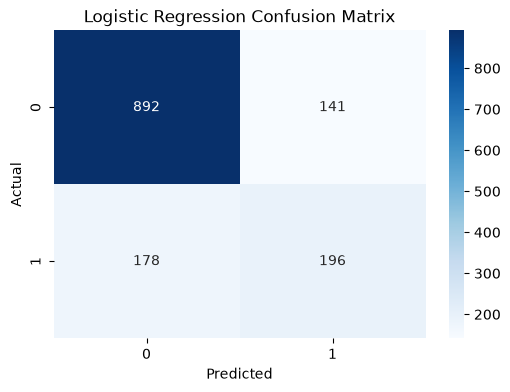

In [67]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [68]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.52      0.55       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



In [69]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 77.33 %


In [70]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
6,MonthlyCharges,0.654086
7,TotalCharges,0.573983
4,PaymentMethod,0.075923
1,InternetService,0.012669
3,TechSupport,-0.318785
2,OnlineSecurity,-0.350291
0,Contract,-0.853556
5,tenure,-1.254924


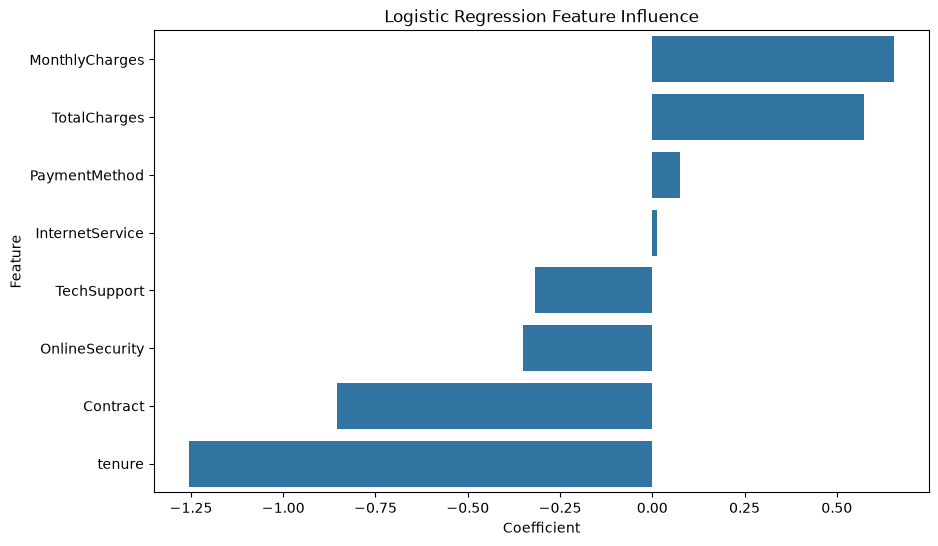

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients.sort_values(
        by='Coefficient',
        ascending=False
    ),
    x='Coefficient',
    y='Feature'
)

plt.title(
    "Logistic Regression Feature Influence"
)

plt.show()

In [72]:
import pickle

pickle.dump(
    logistic_model,
    open(
        "logistic_regression_model.pkl",
        "wb"
    )
)

In [73]:
loaded_model = pickle.load(
    open(
        "logistic_regression_model.pkl",
        "rb"
    )
)

print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


In [74]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred
)

logistic_precision = 0.58

logistic_recall = 0.52

logistic_f1 = 0.55

--------

# Decision Tree Section

--------

## Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm that predicts outcomes by learning a series of decision rules from the training data.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships between variables.


In [75]:
from sklearn.tree import DecisionTreeClassifier

In [76]:
decision_tree = DecisionTreeClassifier( random_state=42 )

In [77]:
decision_tree.fit( X_train, y_train )

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [78]:
y_pred_tree = decision_tree.predict( X_test )

In [79]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(
    f"Decision Tree Accuracy: {tree_accuracy:.4f}"
)

Decision Tree Accuracy: 0.7235


In [80]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

cm_tree

array([[834, 199],
       [190, 184]])

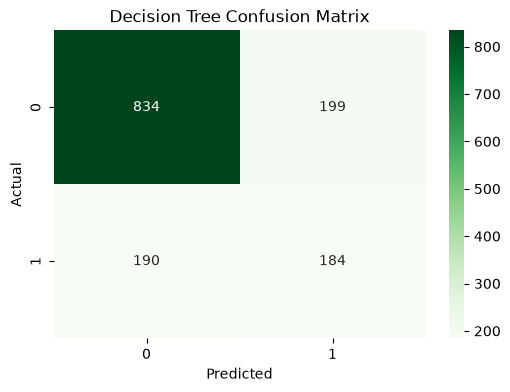

In [81]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [82]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.48      0.49      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.72      0.72      1407



In [83]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1:", tree_f1)

Precision: 0.4804177545691906
Recall: 0.4919786096256685
F1: 0.4861294583883752


In [85]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': decision_tree.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,TotalCharges,0.276174
6,MonthlyCharges,0.253583
0,Contract,0.176114
5,tenure,0.138121
4,PaymentMethod,0.052928
2,OnlineSecurity,0.047775
1,InternetService,0.030253
3,TechSupport,0.025053


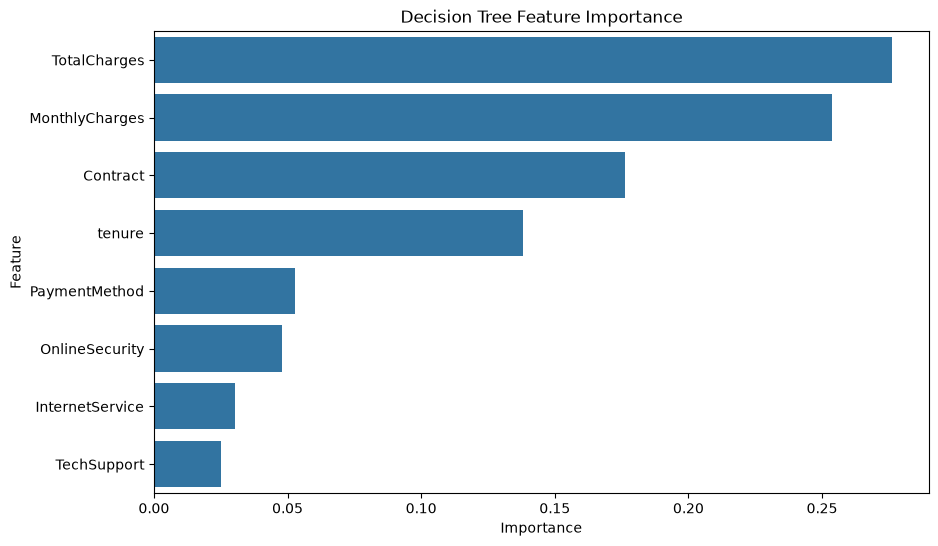

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.show()

In [87]:
pickle.dump(
    decision_tree,
    open(
        "decision_tree_model.pkl",
        "wb"
    )
)

-------

## Comparison Table

-------

In [88]:
comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Logistic Regression': [
        77.33,
        58,
        52,
        55
    ],

    'Decision Tree': [
        72.35,
        48,
        49,
        49
    ]

})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,77.33,72.35
1,Precision,58.00,48.00
2,Recall,52.00,49.00
3,F1 Score,55.00,49.00


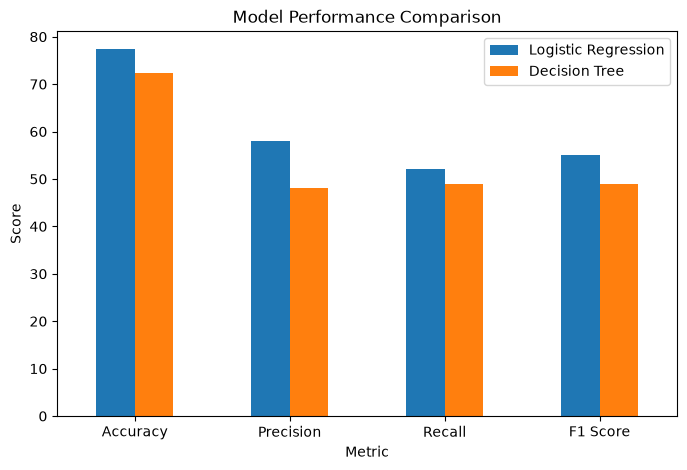

In [89]:
comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

# Conclusion

This project aimed to predict customer churn using machine learning techniques.

After performing data cleaning, exploratory data analysis, feature selection, and preprocessing, two classification models were trained and evaluated:

1. Logistic Regression
2. Decision Tree Classifier

The selected features included:

* Contract
* InternetService
* OnlineSecurity
* TechSupport
* PaymentMethod
* tenure
* MonthlyCharges
* TotalCharges

Performance evaluation showed that Logistic Regression achieved the highest accuracy of 77.33%, outperforming the Decision Tree model, which achieved 72.35%.

Additionally, Logistic Regression demonstrated better Precision, Recall, and F1 Score, indicating stronger overall performance in identifying customers likely to churn.

Based on these results, Logistic Regression was selected as the preferred model for deployment in the Streamlit application.


In [90]:
feature_columns = X.columns.tolist()

print(feature_columns)

['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [91]:
import pickle

pickle.dump(
    feature_columns,
    open(
        "feature_columns.pkl",
        "wb"
    )
)

# Project Summary

#### Dataset: Telco Customer Churn Dataset

#### Objective:
Predict whether a customer is likely to leave the company's services.

#### Selected Features:

* Contract
* InternetService
* OnlineSecurity
* TechSupport
* PaymentMethod
* tenure
* MonthlyCharges
* TotalCharges

#### Models Used:

1. Logistic Regression
2. Decision Tree

#### Results:

### Logistic Regression

* Accuracy: 77.33%
* Precision: 58%
* Recall: 52%
* F1 Score: 55%

### Decision Tree

* Accuracy: 72.35%
* Precision: 48%
* Recall: 49%
* F1 Score: 49%

#### Best Model:
## Logistic Regression

#### Conclusion:
Logistic Regression provided better overall performance and was selected for deployment.
